## Notebook for neighborhood purity computation

- last updated: 10/29/2025

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc

import scipy.io
import scipy.sparse

import matplotlib.pyplot as plt
import seaborn as sns

# rapids-singlecell
import cupy as cp
import rapids_singlecell as rsc

In [2]:
# figure parameter setting
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
mpl.rcParams.update(mpl.rcParamsDefault) #Reset rcParams to default

# Editable text and proper LaTeX fonts in illustrator
# matplotlib.rcParams['ps.useafm'] = True
# Editable fonts. 42 is the magic number
mpl.rcParams['pdf.fonttype'] = 42
sns.set(style='whitegrid', context='paper')
# Set default DPI for saved figures
mpl.rcParams['savefig.dpi'] = 600

# Plotting style function (run this before plotting the final figure)
def set_plotting_style():
    plt.style.use('seaborn-paper')
    plt.rc('axes', labelsize=12)
    plt.rc('axes', titlesize=12)
    plt.rc('xtick', labelsize=10)
    plt.rc('ytick', labelsize=10)
    plt.rc('legend', fontsize=10)
    plt.rc('text.latex', preamble=r'\usepackage{sfmath}')
    plt.rc('xtick.major', pad=2)
    plt.rc('ytick.major', pad=2)
    plt.rc('mathtext', fontset='stixsans', sf='sansserif')
    plt.rc('figure', figsize=[8,8])
    plt.rc('svg', fonttype='none')

In [3]:
import logging
# Suppress INFO-level logs for the entire logger
logging.getLogger().setLevel(logging.WARNING)

In [4]:
# define the figure path
import os
figpath = "/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/zebrahub-multiome-analysis/figures/neighborhood_analysis/"
os.makedirs(figpath, exist_ok=True)
sc.settings.figdir = figpath

In [5]:
# load the master adata object (multiome, all timepoints, all cells from the Seurat processing pipeline - step 1)
# NOTE. 95196 cells
# NOTE that this adata has "RNA" counts in the counts layer
adata = sc.read_h5ad("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data/01_Signac_processed/integrated_RNA_ATAC_counts_RNA.h5ad")
adata

AnnData object with n_obs × n_vars = 95196 × 32057
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'nCount_SCT', 'nFeature_SCT', 'global_annotation', 'prediction.score.Lateral_Mesoderm', 'prediction.score.Neural_Crest', 'prediction.score.Somites', 'prediction.score.Epidermal', 'prediction.score.Neural_Anterior', 'prediction.score.Neural_Posterior', 'prediction.score.Endoderm', 'prediction.score.PSM', 'prediction.score.Differentiating_Neurons', 'prediction.score.Adaxial_Cells', 'prediction.score.NMPs', 'prediction.score.Notochord', 'prediction.score.Muscle', 'prediction.score.unassigned', 'prediction.score.max', 'nCount_peaks_bulk', 'nFeature_peaks_bulk', 'nCount_peaks_celltype', 'nFeature_peaks_celltype', 'nCount_peaks_merged', 'nFeature_peaks_merged', 'SCT.weight', 'peaks_merged.weight', 'nCount_Gene.Activity', 'nFeature_Gene.Activity', 'nCount_peaks_integrated', 'nFe

## Step 0. Check the "weights" between RNA and ATAC for computing WNN

- recap the Figures from the Seurat v4 paper (this is weight (RNA vs ATAC) per-cell metric).
- plotting the RNA weight per cell grouped by the celltypes (or lineages) will show which celltype is better resolved in RNA vs ATAC modality
- 

In [6]:
rna_weights = pd.read_csv("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data/01_Signac_processed/RNA_weights.csv", index_col=0)
rna_weights.head()

,x
1,0.493270
2,0.498962
3,0.572315
4,0.481765
5,0.408465


## Step 1. import the neighborhood information

- Seurat does not save the nearest neighbor (nn) information for RNA or ATAC, individually when WNN was computed. So, we're re-computing the "connectivities" (neighbor graph) using scanpy.
- WNN is imported from the seurat object

In [6]:
# import the PCA and LSI (dim.reductions) to compute the nearest neighbor graph
pca = pd.read_csv("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data/01_Signac_processed/integrated_pca.csv", index_col=0)
pca.head()

lsi = pd.read_csv("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data/01_Signac_processed/integrated_lsi.csv", index_col=0)
lsi.head()

,integratedlsi_1,integratedlsi_2,integratedlsi_3,integratedlsi_4,integratedlsi_5,integratedlsi_6,integratedlsi_7,integratedlsi_8,integratedlsi_9,integratedlsi_10,...,integratedlsi_41,integratedlsi_42,integratedlsi_43,integratedlsi_44,integratedlsi_45,integratedlsi_46,integratedlsi_47,integratedlsi_48,integratedlsi_49,integratedlsi_50
AAACAGCCACCTAAGC-1_1,-0.158541,-0.859215,2.383088,0.959107,2.666897,-1.699729,1.353891,-1.151889,-0.356146,0.117458,...,-3.566609,-0.934853,0.099280,0.002932,-0.302558,2.392025,-0.260764,-2.388533,0.076997,-0.692057
AAACAGCCAGGGAGGA-1_1,0.274469,-0.804502,0.145722,-0.406308,0.475707,1.047771,-0.074658,-0.755766,-0.035674,1.429914,...,1.334581,1.780359,1.075075,-0.016776,-1.261588,-1.826283,0.197267,0.936461,-1.053473,1.443473
AAACAGCCATAGACCC-1_1,-1.277847,1.424970,-1.340787,-0.917404,1.769696,0.636748,0.634659,-0.712751,-0.582033,-1.482544,...,0.424773,0.786675,-1.264275,2.783100,-0.483104,-0.868756,-0.166610,-2.258445,-1.004266,-1.769703
AAACATGCAAACTCAT-1_1,-0.236289,0.104044,-1.128835,1.334319,0.830425,1.517093,0.124041,0.972479,-0.610059,0.355354,...,-1.797116,0.603657,-1.548172,-0.521610,0.461745,-0.114524,1.027203,-0.292045,1.993633,1.053841
AAACATGCAAGGACCA-1_1,1.233376,1.066662,-0.329429,-0.052175,-0.127930,-0.366875,0.684775,-0.888543,-0.049728,0.296817,...,1.197450,-1.021409,0.124640,-0.110493,-1.099886,0.903956,0.246317,-0.222636,-0.389359,1.504342


In [7]:
# reindex the PCA using the cell_ids from adata_rna.obs_names
pca_aligned = pca.reindex(adata.obs_names)
#pca_aligned.head()

lsi_aligned = lsi.reindex(adata.obs_names)
#lsi_aligned.head()

# add them to the obsm slot
adata.obsm["X_pca"] = pca_aligned.values
adata.obsm["X_lsi"] = lsi_aligned.values

# remove the first LSI componenet as it's usually correlated with the sequencing depth
adata.obsm['X_lsi'] = adata.obsm['X_lsi'][:,1:]

In [8]:
# need to specify which dim.reduction, and keys to be used
# RNA: Use the PCA components 1:50
sc.pp.neighbors(adata, n_neighbors=30, n_pcs=50, use_rep="X_pca", key_added="RNA")
# ATAC: Use the LSI componenets 2:40
sc.pp.neighbors(adata, n_neighbors=30, n_pcs=39, use_rep="X_lsi", key_added="ATAC")
adata

AnnData object with n_obs × n_vars = 95196 × 32057
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'nCount_SCT', 'nFeature_SCT', 'global_annotation', 'prediction.score.Lateral_Mesoderm', 'prediction.score.Neural_Crest', 'prediction.score.Somites', 'prediction.score.Epidermal', 'prediction.score.Neural_Anterior', 'prediction.score.Neural_Posterior', 'prediction.score.Endoderm', 'prediction.score.PSM', 'prediction.score.Differentiating_Neurons', 'prediction.score.Adaxial_Cells', 'prediction.score.NMPs', 'prediction.score.Notochord', 'prediction.score.Muscle', 'prediction.score.unassigned', 'prediction.score.max', 'nCount_peaks_bulk', 'nFeature_peaks_bulk', 'nCount_peaks_celltype', 'nFeature_peaks_celltype', 'nCount_peaks_merged', 'nFeature_peaks_merged', 'SCT.weight', 'peaks_merged.weight', 'nCount_Gene.Activity', 'nFeature_Gene.Activity', 'nCount_peaks_integrated', 'nFe

In [10]:
adata.obsp["RNA_connectivities"].shape

(95196, 95196)

### load the WNN
- load the WNN exported from the Seurat object (95196 cells)

In [9]:
# Read the Matrix Market file and cell names
def load_wnn_graph(mtx_file, cell_names_file, adata):
    """
    Load WNN graph from R export and add to AnnData object
    """
    # Read the sparse matrix
    wsnn_matrix = scipy.io.mmread(mtx_file)
    
    # Convert to CSR format (more efficient for most operations)
    wsnn_matrix = wsnn_matrix.tocsr()
    
    # Read cell names
    with open(cell_names_file, 'r') as f:
        seurat_cell_names = [line.strip() for line in f.readlines()]
    
    print(f"WNN matrix shape: {wsnn_matrix.shape}")
    print(f"Number of cell names: {len(seurat_cell_names)}")
    print(f"AnnData shape: {adata.shape}")
    
    # Quick check: if lengths match, check if cell order is identical
    adata_cells = adata.obs_names.tolist()
    
    if len(seurat_cell_names) == len(adata_cells):
        print("Same number of cells - checking if order matches...")
        
        # Check first 10 and last 10 cells for quick verification
        n_check = min(10, len(seurat_cell_names))
        first_match = all(seurat_cell_names[i] == adata_cells[i] for i in range(n_check))
        last_match = all(seurat_cell_names[-(i+1)] == adata_cells[-(i+1)] for i in range(n_check))
        
        if first_match and last_match:
            print("✓ Cell orders appear to match! Skipping reordering.")
            return wsnn_matrix
        else:
            print("✗ Cell orders don't match - will need reordering")
    else:
        print("Different number of cells - will need subsetting and reordering")
    
    # Fallback: original reordering logic
    print("Proceeding with cell alignment...")
    
    # Check if all AnnData cells are in Seurat cell names
    adata_cells_set = set(adata_cells)
    seurat_cells_set = set(seurat_cell_names)
    
    missing_in_seurat = adata_cells_set - seurat_cells_set
    extra_in_seurat = seurat_cells_set - adata_cells_set
    
    print(f"Cells in AnnData: {len(adata_cells_set)}")
    print(f"Cells in Seurat: {len(seurat_cells_set)}")
    print(f"Missing in Seurat: {len(missing_in_seurat)}")
    print(f"Extra in Seurat: {len(extra_in_seurat)}")
    
    # Create mapping from Seurat order to AnnData order
    seurat_to_adata_idx = {}
    for i, cell in enumerate(seurat_cell_names):
        if cell in adata_cells_set:
            adata_idx = adata_cells.index(cell)
            seurat_to_adata_idx[i] = adata_idx
    
    # Get indices of cells that exist in both
    keep_seurat_idx = list(seurat_to_adata_idx.keys())
    keep_adata_idx = list(seurat_to_adata_idx.values())
    
    # Subset and reorder the matrix
    wsnn_subset = wsnn_matrix[keep_seurat_idx, :][:, keep_seurat_idx]
    
    # Reorder to match AnnData cell order
    reorder_idx = np.argsort(keep_adata_idx)
    final_seurat_idx = [keep_seurat_idx[i] for i in reorder_idx]
    wsnn_reordered = wsnn_matrix[final_seurat_idx, :][:, final_seurat_idx]
    
    return wsnn_reordered

# Usage
output_dir = "/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data/01_Signac_processed"
wsnn_matrix = load_wnn_graph(
    mtx_file=f"{output_dir}/wsnn_matrix.mtx",
    cell_names_file=f"{output_dir}/cell_names.txt",
    adata=adata
)

# Add to AnnData object
adata.obsp["connectivities_wnn"] = wsnn_matrix
print(f"Successfully added WNN connectivities with shape: {wsnn_matrix.shape}")

WNN matrix shape: (95196, 95196)
Number of cell names: 95196
AnnData shape: (95196, 32057)
Same number of cells - checking if order matches...
✓ Cell orders appear to match! Skipping reordering.
Successfully added WNN connectivities with shape: (95196, 95196)


### computing the leiden clustering

- NOTE that we have computed the leiden clustering using WNN (Seurat) - which yielded 40 clusters at 0.8 resolution.
- NOTE that Seurat merges small clusters (too few cells) into the nearest clusters.

In [12]:
adata

AnnData object with n_obs × n_vars = 95196 × 32057
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'nCount_SCT', 'nFeature_SCT', 'global_annotation', 'prediction.score.Lateral_Mesoderm', 'prediction.score.Neural_Crest', 'prediction.score.Somites', 'prediction.score.Epidermal', 'prediction.score.Neural_Anterior', 'prediction.score.Neural_Posterior', 'prediction.score.Endoderm', 'prediction.score.PSM', 'prediction.score.Differentiating_Neurons', 'prediction.score.Adaxial_Cells', 'prediction.score.NMPs', 'prediction.score.Notochord', 'prediction.score.Muscle', 'prediction.score.unassigned', 'prediction.score.max', 'nCount_peaks_bulk', 'nFeature_peaks_bulk', 'nCount_peaks_celltype', 'nFeature_peaks_celltype', 'nCount_peaks_merged', 'nFeature_peaks_merged', 'SCT.weight', 'peaks_merged.weight', 'nCount_Gene.Activity', 'nFeature_Gene.Activity', 'nCount_peaks_integrated', 'nFe

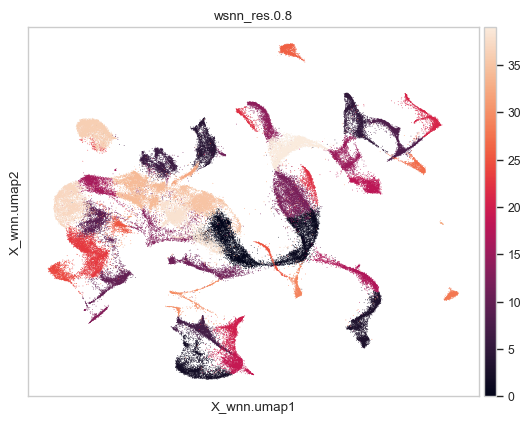

In [104]:
sc.pl.embedding(adata, basis="X_wnn.umap", color="wsnn_res.0.8")

In [10]:
import sys
sys.path.append('../../scripts/utils')
from clustering import *

In [96]:
# # perform leiden clustering
# rsc.tl.leiden(adata, key_added="RNA_leiden", neighbors_key="RNA", resolution=2.12)
# rsc.tl.leiden(adata, key_added="ATAC_leiden", neighbors_key="ATAC", resolution=1.15)


In [15]:
# leiden clustering for RNA
for res in [0.7, 0.8, 1, 1.2]:
    rsc.tl.leiden(adata, key_added=f"RNA_leiden_{res}", neighbors_key="RNA", resolution=res)
    group_singletons_seurat_style(adata, leiden_key=f"RNA_leiden_{res}", adjacency_key="RNA_connectivities",
                                  merged_key_suffix="merged")
    print(adata.obs[f"RNA_leiden_{res}_merged"].unique())

['9', '19', '17', '5', '18', ..., '7', '0', '14', '4', '2']
Length: 21
Categories (21, object): ['0', '1', '10', '11', ..., '6', '7', '8', '9']
['11', '22', '20', '16', '21', ..., '6', '0', '7', '4', '2']
Length: 23
Categories (23, object): ['0', '1', '10', '11', ..., '6', '7', '8', '9']
['8', '23', '9', '16', '10', ..., '1', '2', '22', '6', '4']
Length: 25
Categories (25, object): ['0', '1', '10', '11', ..., '6', '7', '8', '9']
['9', '2', '10', '18', '11', ..., '24', '6', '8', '4', '0']
Length: 27
Categories (27, object): ['0', '1', '10', '11', ..., '6', '7', '8', '9']


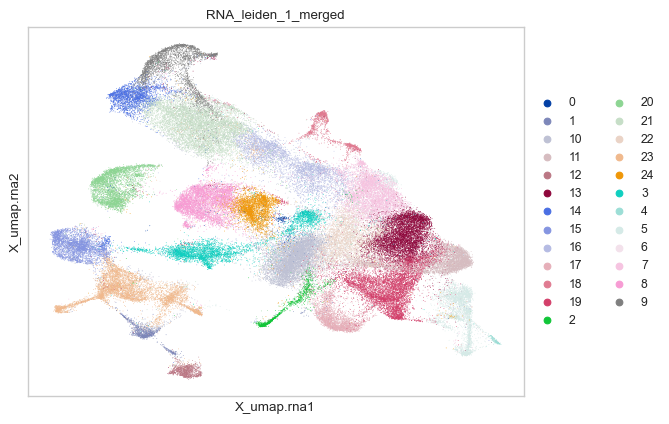

In [76]:
res=1
sc.pl.embedding(adata, basis="X_umap.rna",color=f"RNA_leiden_{res}_merged")

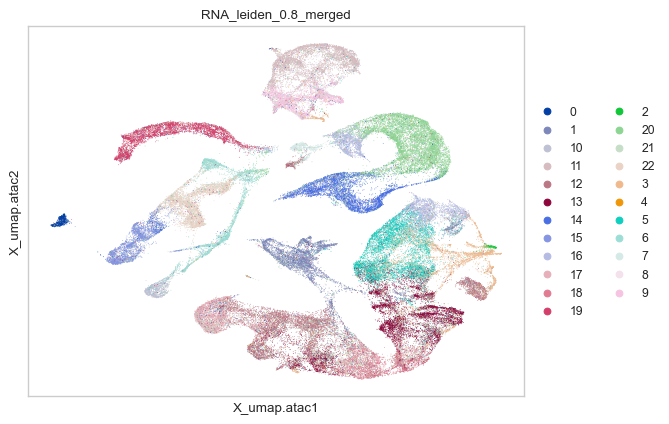

In [17]:
res=0.8
sc.pl.embedding(adata, basis="X_umap.atac",color=f"RNA_leiden_{res}_merged")

In [18]:
# leiden clustering for ATAC
for res in [0.4, 0.5, 0.7, 1]:
    rsc.tl.leiden(adata, key_added=f"ATAC_leiden_{res}", neighbors_key="ATAC", resolution=res)
    group_singletons_seurat_style(adata, leiden_key=f"ATAC_leiden_{res}", adjacency_key="ATAC_connectivities",
                                  merged_key_suffix="merged")
    print(adata.obs[f"ATAC_leiden_{res}_merged"].unique())

['5', '6', '11', '18', '0', ..., '7', '15', '2', '10', '20']
Length: 21
Categories (21, object): ['0', '1', '10', '11', ..., '6', '7', '8', '9']
['16', '25', '15', '10', '24', ..., '11', '13', '19', '14', '12']
Length: 26
Categories (26, object): ['0', '1', '10', '11', ..., '6', '7', '8', '9']
['16', '28', '7', '3', '2', ..., '14', '21', '17', '19', '23']
Length: 30
Categories (30, object): ['0', '1', '10', '11', ..., '6', '7', '8', '9']
['23', '7', '8', '18', '29', ..., '2', '12', '10', '30', '32']
Length: 33
Categories (33, object): ['0', '1', '10', '11', ..., '6', '7', '8', '9']


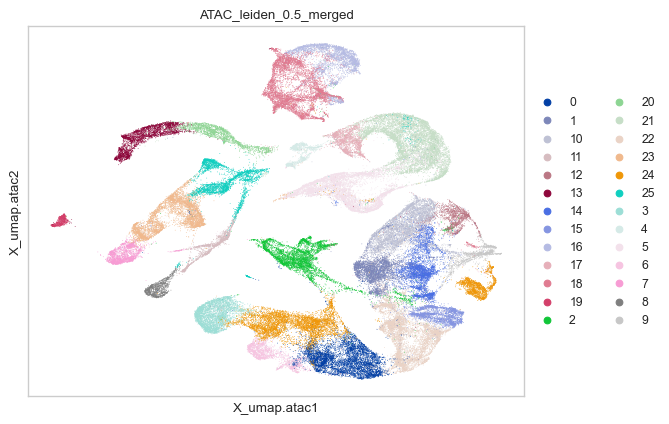

In [19]:
res=0.5
sc.pl.embedding(adata, basis="X_umap.atac",color=f"ATAC_leiden_{res}_merged")

In [20]:
# leiden clustering for Joint (WNN)
for res in [0.3, 0.35, 0.4, 0.5, 0.8]:
    rsc.tl.leiden(adata, key_added=f"WNN_leiden_{res}", obsp="connectivities_wnn", resolution=res)
    group_singletons_seurat_style(adata, leiden_key=f"WNN_leiden_{res}", adjacency_key="connectivities_wnn",
                                  merged_key_suffix="merged")
    print(adata.obs[f"WNN_leiden_{res}_merged"].unique())

['10', '20', '12', '8', '5', ..., '9', '15', '3', '2', '18']
Length: 21
Categories (21, object): ['0', '1', '10', '11', ..., '6', '7', '8', '9']
['14', '26', '19', '15', '25', ..., '16', '4', '3', '21', '23']
Length: 27
Categories (27, object): ['0', '1', '10', '11', ..., '6', '7', '8', '9']
['18', '29', '21', '20', '11', ..., '6', '4', '27', '19', '28']
Length: 30
Categories (30, object): ['0', '1', '10', '11', ..., '6', '7', '8', '9']
['19', '32', '23', '15', '7', ..., '5', '28', '30', '20', '31']
Length: 34
Categories (34, object): ['0', '1', '10', '11', ..., '6', '7', '8', '9']
['18', '37', '27', '23', '13', ..., '25', '15', '40', '22', '36']
Length: 41
Categories (41, object): ['0', '1', '10', '11', ..., '6', '7', '8', '9']


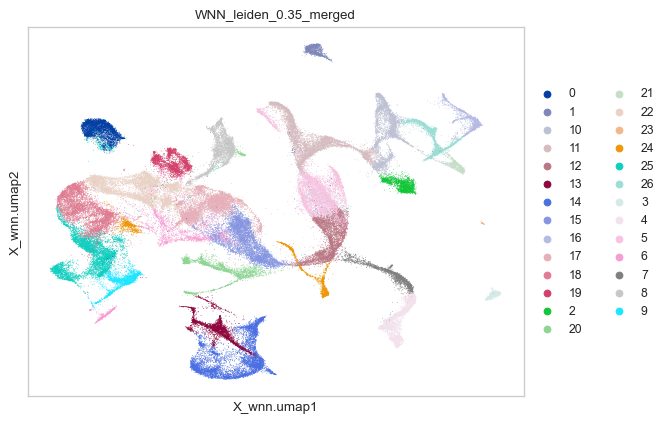

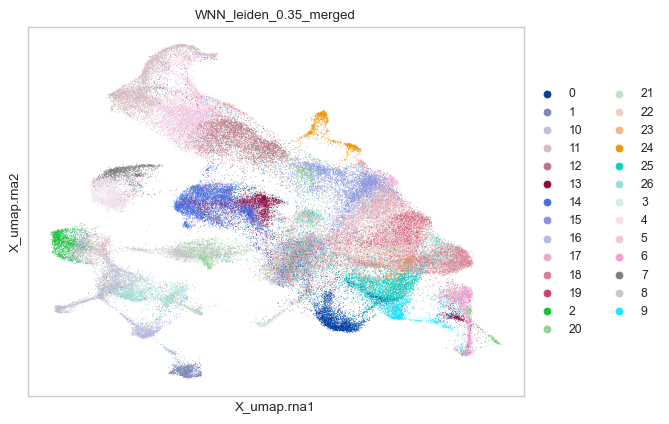

In [21]:
res=0.35
sc.pl.embedding(adata, basis="X_wnn.umap", color=f"WNN_leiden_{res}_merged")
sc.pl.embedding(adata, basis="X_umap.rna", color=f"WNN_leiden_{res}_merged")

## Load the module to compute the metrics for data integration

In [11]:
# Add scripts directory to path for importing our custom modules
sys.path.append('../../scripts')
from neighborhood_purity_module import *

ModuleNotFoundError: No module named 'neighborhood_purity_module'

In [24]:
adata

AnnData object with n_obs × n_vars = 95196 × 32057
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'nCount_SCT', 'nFeature_SCT', 'global_annotation', 'prediction.score.Lateral_Mesoderm', 'prediction.score.Neural_Crest', 'prediction.score.Somites', 'prediction.score.Epidermal', 'prediction.score.Neural_Anterior', 'prediction.score.Neural_Posterior', 'prediction.score.Endoderm', 'prediction.score.PSM', 'prediction.score.Differentiating_Neurons', 'prediction.score.Adaxial_Cells', 'prediction.score.NMPs', 'prediction.score.Notochord', 'prediction.score.Muscle', 'prediction.score.unassigned', 'prediction.score.max', 'nCount_peaks_bulk', 'nFeature_peaks_bulk', 'nCount_peaks_celltype', 'nFeature_peaks_celltype', 'nCount_peaks_merged', 'nFeature_peaks_merged', 'SCT.weight', 'peaks_merged.weight', 'nCount_Gene.Activity', 'nFeature_Gene.Activity', 'nCount_peaks_integrated', 'nFe

In [28]:
# import the metadata
metadata = pd.read_csv("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data/01_Signac_processed/master_rna_atac_metadata.csv", index_col=0)
metadata.head()

,orig_ident,nCount_RNA,nFeature_RNA,nCount_ATAC,nFeature_ATAC,nucleosome_signal,nucleosome_percentile,TSS_enrichment,TSS_percentile,nCount_SCT,...,dataset,integrated_weight,peaks_integrated_weight,wsnn_res_0_8,seurat_clusters,data_source,annotation_ML,scANVI_zscape,annotation_ML_coarse,dev_stage
AAACAGCCACCTAAGC-1_1,SeuratProject,6522.0,2317,21425.0,9781,0.571984,0.40,4.488213,0.48,5661.0,...,TDR118,4.062589e-01,0.593741,2,10,multiome,epidermis,contains head vasculature?,epidermis,15somites
AAACAGCCAGGGAGGA-1_1,SeuratProject,6100.0,2319,10334.0,5028,0.448143,0.13,4.795205,0.75,5553.0,...,TDR118,7.616462e-01,0.238354,8,16,multiome,pronephros,vascular smooth muscle,pronephros,15somites
AAACAGCCATAGACCC-1_1,SeuratProject,12581.0,3467,51485.0,19874,0.514213,0.24,5.238692,0.92,5781.0,...,TDR118,5.938950e-08,1.000000,6,14,multiome,hindbrain,fin bud mesoderm (pectoral),hindbrain,15somites
AAACATGCAAACTCAT-1_1,SeuratProject,5642.0,2145,19812.0,9183,0.673319,0.85,4.409525,0.41,5363.0,...,TDR118,3.694048e-01,0.630595,0,0,multiome,spinal_cord,posterior spinal cord progenitors,spinal_cord,15somites
AAACATGCAAGGACCA-1_1,SeuratProject,2691.0,838,5182.0,2565,0.394904,0.06,4.939061,0.83,4727.0,...,TDR118,3.265597e-02,0.967344,23,3,multiome,neural_optic2,pharynx,neural_optic,15somites


In [29]:
adata.obs["annotation_ML"] = adata.obs_names.map(metadata["annotation_ML"])
adata.obs["annotation_ML_coarse"] = adata.obs_names.map(metadata["annotation_ML_coarse"])
adata.obs["timepoint"] = adata.obs_names.map(metadata["dev_stage"])

In [78]:
# Define connectivity matrices (for neighborhood purity analysis) - Updated for Zebrahub data
connectivity_keys = {
    'RNA': 'RNA_connectivities',      # RNA neighborhood graph
    'ATAC': 'ATAC_connectivities',    # ATAC neighborhood graph  
    'WNN': 'connectivities_wnn'       # Weighted nearest neighbor graph
}

# Define embedding keys (for clustering and scIB metrics) - Updated for Zebrahub data
embedding_keys = {
    'RNA': 'X_pca',          # RNA PCA embedding
    'ATAC': 'X_lsi',         # ATAC LSI embedding  
    'WNN': 'X_wnn.umap'      # WNN embedding
}

# Define cluster label keys (for cross-modality validation) - Updated for Zebrahub data
cluster_keys = {
    'RNA': 'RNA_leiden_1_merged',      # RNA leiden clusters at resolution 0.8
    'ATAC': 'ATAC_leiden_0.5_merged',    # ATAC leiden clusters at resolution 0.8
    'WNN': 'WNN_leiden_0.35_merged',
    #'WNN': 'wsnn_res.0.8'        # WNN clusters at resolution 0.8
}

# Metadata key for biological validation
metadata_key = 'annotation_ML_coarse'  # or other metadata in adata.obs

# Analysis parameters
leiden_resolution = 0.8    # Resolution for leiden clustering
k_neighbors = 30           # Number of neighbors for purity analysis
n_neighbors_clustering = 15 # Number of neighbors for clustering

print("✓ Configuration completed")

✓ Configuration completed


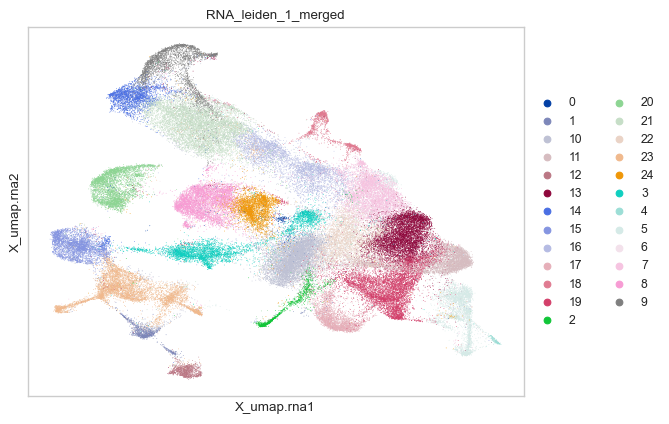

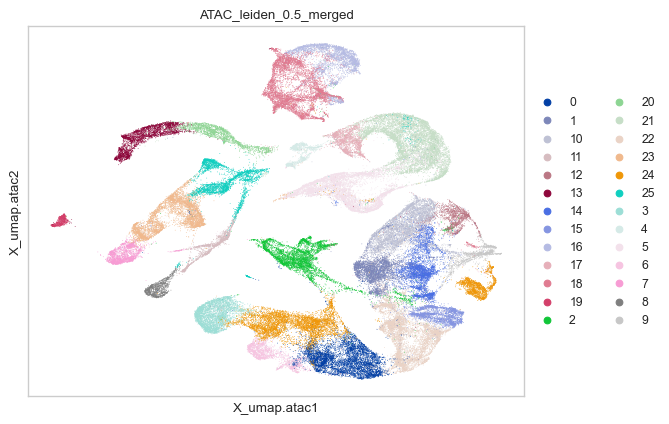

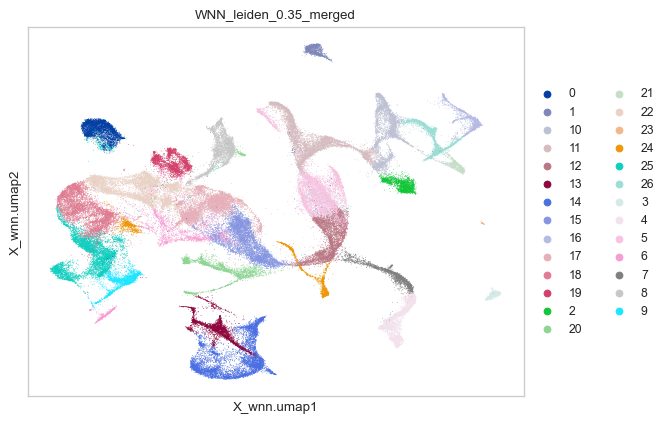

In [79]:
# save the leiden clustering results
sc.pl.embedding(adata, basis="X_umap.rna", color=cluster_keys["RNA"], save="_rna_leiden_clusters.png")
sc.pl.embedding(adata, basis="X_umap.atac", color=cluster_keys["ATAC"], save="_atac_leiden_clusters.png")
sc.pl.embedding(adata, basis="X_wnn.umap", color=cluster_keys["WNN"], save="_wnn_leiden_clusters.png")

In [32]:
# 1. Neighborhood Purity Analysis
# 
# **Objective**: Measure how well cells of the same biological type cluster together in their k-nearest neighborhood.
# 
# **Key Insight**: Good embeddings should have high neighborhood purity - cells should be surrounded by neighbors of the same cell type.
# 
# **Expected Results**: WNN (joint) embedding should show higher purity scores than individual RNA or ATAC modalities.

# %%
print("=" * 60)
print("1. NEIGHBORHOOD PURITY ANALYSIS")
print("=" * 60)

# Compute purity scores using pre-computed connectivities
purity_results = compute_multimodal_knn_purity(
    adata=adata,
    connectivity_keys=connectivity_keys,
    metadata_key=metadata_key,
    k=k_neighbors
)

# Summarize purity results
print(f"\n📊 Purity Analysis Summary ({metadata_key}):")
summary_purity = summarize_purity_scores(purity_results, adata, metadata_key)
print(summary_purity[summary_purity['Metadata'] == 'Overall'][['Modality', 'Mean_Purity', 'Std_Purity']])



1. NEIGHBORHOOD PURITY ANALYSIS
✓ Computed purity for RNA modality using RNA_connectivities
✓ Computed purity for ATAC modality using ATAC_connectivities
✓ Computed purity for WNN modality using connectivities_wnn

📊 Purity Analysis Summary (annotation_ML_coarse):
   Modality  Mean_Purity  Std_Purity
0       RNA     0.647778    0.329939
33     ATAC     0.898723    0.200665
66      WNN     0.958101    0.128130


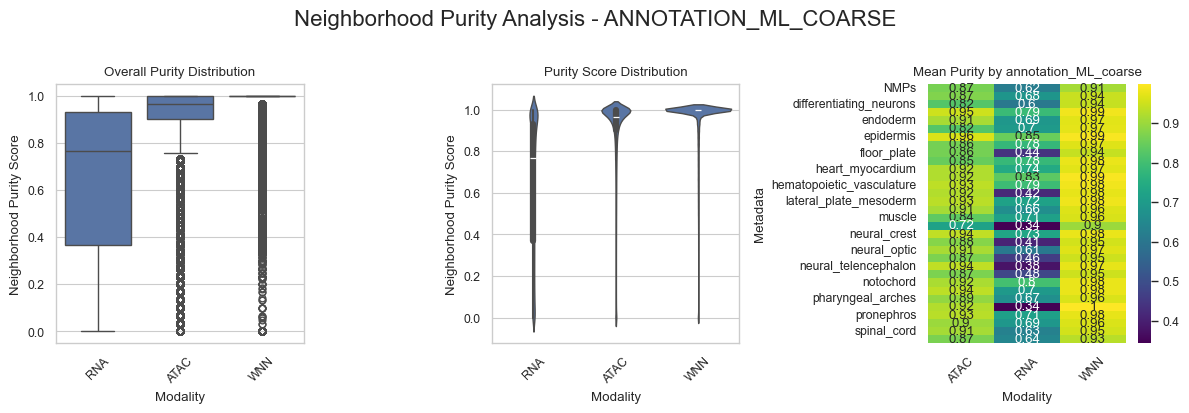

✓ Added purity scores to adata.obs for metadata: annotation_ML_coarse


In [35]:
### Visualize Neighborhood Purity Results
# Create comprehensive purity comparison plots
fig_purity = plot_purity_comparison(
    purity_results, 
    adata, 
    metadata_key,
    figsize=(12, 4)
)

plt.suptitle(f'Neighborhood Purity Analysis - {metadata_key.upper()}', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(figpath + "nn_purity_celltype.pdf")
plt.show()

# Add purity scores to AnnData for later analysis
add_purity_to_adata(adata, purity_results, metadata_key)

### Computing the neighborhood purity for the leiden clusters (from RNA, ATAC, and Joint, respectively)

- the idea is to compute the neighborhood purity using the "leiden clusters" computed from each modality



In [68]:
def compute_comprehensive_neighborhood_purity(
    adata,
    connectivity_keys = None,
    cluster_keys = None,
    k_neighbors = 30
):
    """
    Compute neighborhood purity for all combinations of connectivity matrices and clustering metadata
    """
    
    if connectivity_keys is None:
        connectivity_keys = {
            'RNA': 'RNA_connectivities',
            'ATAC': 'ATAC_connectivities',
            'WNN': 'connectivities_wnn'
        }
    
    if cluster_keys is None:
        cluster_keys = {
            'RNA': 'RNA_leiden_0.8_merged',
            'ATAC': 'ATAC_leiden_0.5_merged',
            'WNN': 'WNN_leiden_0.35_merged'
        }
    
    print("Computing comprehensive neighborhood purity analysis...")
    
    # Store all results
    all_purity_results = {}
    
    # For each clustering metadata
    for cluster_name, cluster_key in cluster_keys.items():
        print(f"\nAnalyzing {cluster_name} clusters ({cluster_key})...")
        
        # Check if cluster key exists
        if cluster_key not in adata.obs.columns:
            print(f"Warning: {cluster_key} not found in adata.obs")
            continue
        
        # Compute purity scores using pre-computed connectivities
        purity_results = compute_multimodal_knn_purity(
            adata=adata,
            connectivity_keys=connectivity_keys,
            metadata_key=cluster_key,
            k=k_neighbors
        )
        
        # Store results
        all_purity_results[cluster_name] = purity_results
        
        # Quick summary
        summary_purity = summarize_purity_scores(purity_results, adata, cluster_key)
        overall_summary = summary_purity[summary_purity['Metadata'] == 'Overall'][['Modality', 'Mean_Purity', 'Std_Purity']]
        print(f"Purity Summary for {cluster_name} clusters:")
        print(overall_summary.to_string(index=False))
    
    return all_purity_results

def plot_comprehensive_neighborhood_purity(all_purity_results, adata, plot_type="violin", figsize=(15, 5)):
    """
    Create 3 subplots showing neighborhood purity:
    - Each subplot = one clustering metadata  
    - Each subplot has 3 violin plots or boxplots for RNA, ATAC, WNN neighborhood purity
    
    Parameters:
    -----------
    plot_type : str, default="violin"
        Type of plot to create: "violin" or "boxplot"
    """
    
    cluster_keys = {
        'RNA': 'RNA_leiden_0.8_merged',
        'ATAC': 'ATAC_leiden_0.5_merged',
        'WNN': 'WNN_leiden_0.35_merged'
    }
    
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    
    subplot_titles = list(all_purity_results.keys())
    
    for i, (cluster_name, purity_results) in enumerate(all_purity_results.items()):
        
        # Prepare data for this subplot
        plot_data = []
        
        for modality_name, (purity_scores, _) in purity_results.items():  # Fixed syntax error
            if purity_scores is None:
                continue
                
            # Add each cell's purity score
            for score in purity_scores:
                plot_data.append({
                    'Neighborhood_Type': modality_name,
                    'Purity_Score': score
                })
        
        if not plot_data:
            axes[i].text(0.5, 0.5, 'No Data', ha='center', va='center', transform=axes[i].transAxes)
            axes[i].set_title(f'{cluster_name} Clusters')
            continue
        
        plot_df = pd.DataFrame(plot_data)
        
        # Create plot based on plot_type
        if plot_type.lower() == "violin":
            sns.violinplot(data=plot_df, x='Neighborhood_Type', y='Purity_Score', ax=axes[i])
        elif plot_type.lower() == "boxplot":
            sns.boxplot(data=plot_df, x='Neighborhood_Type', y='Purity_Score', ax=axes[i],
                       showfliers=False)  # removing the outlier dots for boxplots
        else:
            raise ValueError("plot_type must be either 'violin' or 'boxplot'")
        
        # Customize subplot
        axes[i].set_title(f'{cluster_name} Clusters\n({cluster_keys[cluster_name]})')
        axes[i].set_xlabel('Neighborhood Type')
        axes[i].set_ylabel('Neighborhood Purity Score')
        axes[i].set_ylim(0, 1.1)
        axes[i].grid(True, alpha=0.3)
        
        # Add mean values as text
        for j, neighborhood_type in enumerate(['RNA', 'ATAC', 'WNN']):
            if neighborhood_type in plot_df['Neighborhood_Type'].values:
                mean_purity = plot_df[plot_df['Neighborhood_Type'] == neighborhood_type]['Purity_Score'].mean()
                axes[i].text(j, mean_purity + 0.05, f'{mean_purity:.3f}', 
                           ha='center', va='bottom', fontweight='bold', fontsize=10)
    
    plt.tight_layout()
    return fig

# Usage examples:
# For violin plots (default):
fig_violin = plot_comprehensive_neighborhood_purity(all_purity_results, adata, plot_type="violin")

# For boxplots:
fig_boxplot = plot_comprehensive_neighborhood_purity(all_purity_results, adata, plot_type="boxplot")



=== Comprehensive Neighborhood Purity Analysis ===
Testing how well each neighborhood type preserves each clustering approach
Computing comprehensive neighborhood purity analysis...

Analyzing RNA clusters (RNA_leiden_1_merged)...
✓ Computed purity for RNA modality using RNA_connectivities
✓ Computed purity for ATAC modality using ATAC_connectivities
✓ Computed purity for WNN modality using connectivities_wnn
Purity Summary for RNA clusters:
Modality  Mean_Purity  Std_Purity
     RNA     0.875713    0.182326
    ATAC     0.599022    0.325344
     WNN     0.697648    0.325393

Analyzing ATAC clusters (ATAC_leiden_0.5_merged)...
✓ Computed purity for RNA modality using RNA_connectivities
✓ Computed purity for ATAC modality using ATAC_connectivities
✓ Computed purity for WNN modality using connectivities_wnn
Purity Summary for ATAC clusters:
Modality  Mean_Purity  Std_Purity
     RNA     0.615798    0.327429
    ATAC     0.939351    0.137335
     WNN     0.910865    0.210311

Analyzing WN

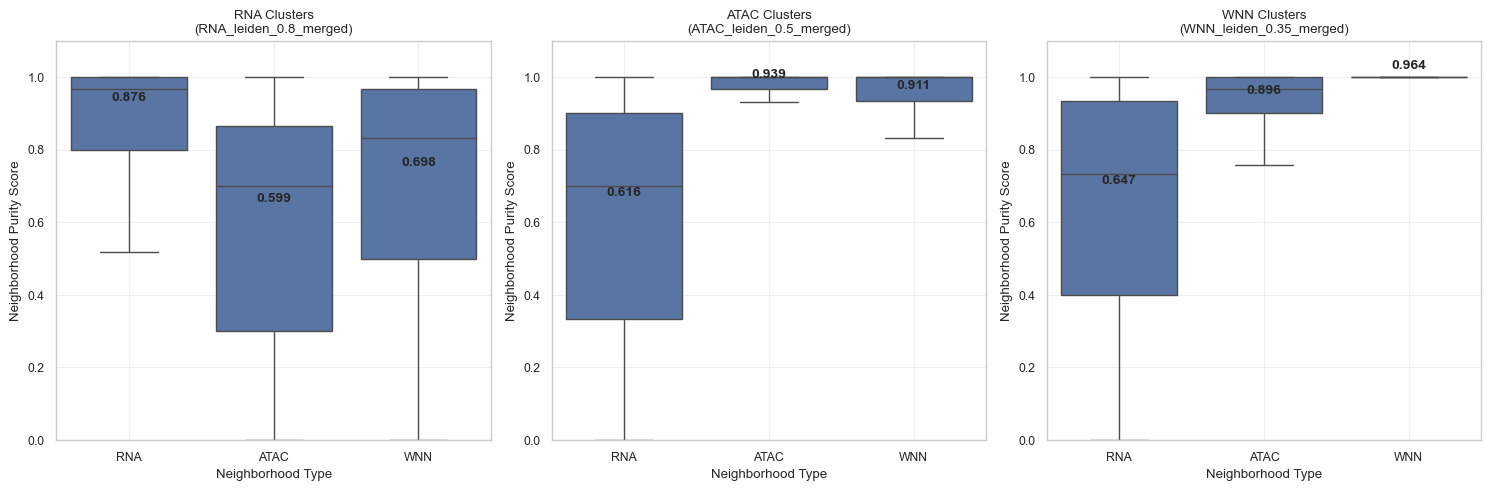


=== Comprehensive Summary ===
Mean Purity Scores:
Neighborhood   ATAC    RNA    WNN
Clustering                       
ATAC          0.939  0.616  0.911
RNA           0.599  0.876  0.698
WNN           0.896  0.647  0.964

=== Interpretation Guide ===
Higher purity = neighborhood better preserves the clustering
Each subplot shows how well RNA/ATAC/WNN neighborhoods preserve that modality's clusters
Diagonal should generally be highest (e.g., RNA neighborhoods best preserve RNA clusters)


In [80]:
# Complete workflow for comprehensive neighborhood purity analysis
    
# Define keys
connectivity_keys = {
    'RNA': 'RNA_connectivities',
    'ATAC': 'ATAC_connectivities',
    'WNN': 'connectivities_wnn'
}

cluster_keys = {
    'RNA': 'RNA_leiden_1_merged',
    'ATAC': 'ATAC_leiden_0.5_merged',
    'WNN': 'WNN_leiden_0.35_merged'
}

print("=== Comprehensive Neighborhood Purity Analysis ===")
print("Testing how well each neighborhood type preserves each clustering approach")

# Compute all purity combinations
all_purity_results = compute_comprehensive_neighborhood_purity(
    adata, connectivity_keys, cluster_keys, k_neighbors=30
)

# Create visualization
fig = plot_comprehensive_neighborhood_purity(all_purity_results, adata, plot_type="boxplot")
plt.savefig(figpath + "neighborhood_purity_boxplots_all.pdf")
plt.show()

# Create summary table
print("\n=== Comprehensive Summary ===")
summary_data = []

for cluster_name, purity_results in all_purity_results.items():
    for modality_name, (purity_scores, _) in purity_results.items():
        if purity_scores is not None:
            summary_data.append({
                'Clustering': cluster_name,
                'Neighborhood': modality_name,
                'Mean_Purity': np.mean(purity_scores),
                'Std_Purity': np.std(purity_scores),
                'N_cells': len(purity_scores)
            })

summary_df = pd.DataFrame(summary_data)

# Pivot for better readability
pivot_summary = summary_df.pivot(index='Clustering', columns='Neighborhood', values='Mean_Purity')
print("Mean Purity Scores:")
print(pivot_summary.round(3))

# Additional interpretation
print("\n=== Interpretation Guide ===")
print("Higher purity = neighborhood better preserves the clustering")
print("Each subplot shows how well RNA/ATAC/WNN neighborhoods preserve that modality's clusters")
print("Diagonal should generally be highest (e.g., RNA neighborhoods best preserve RNA clusters)")

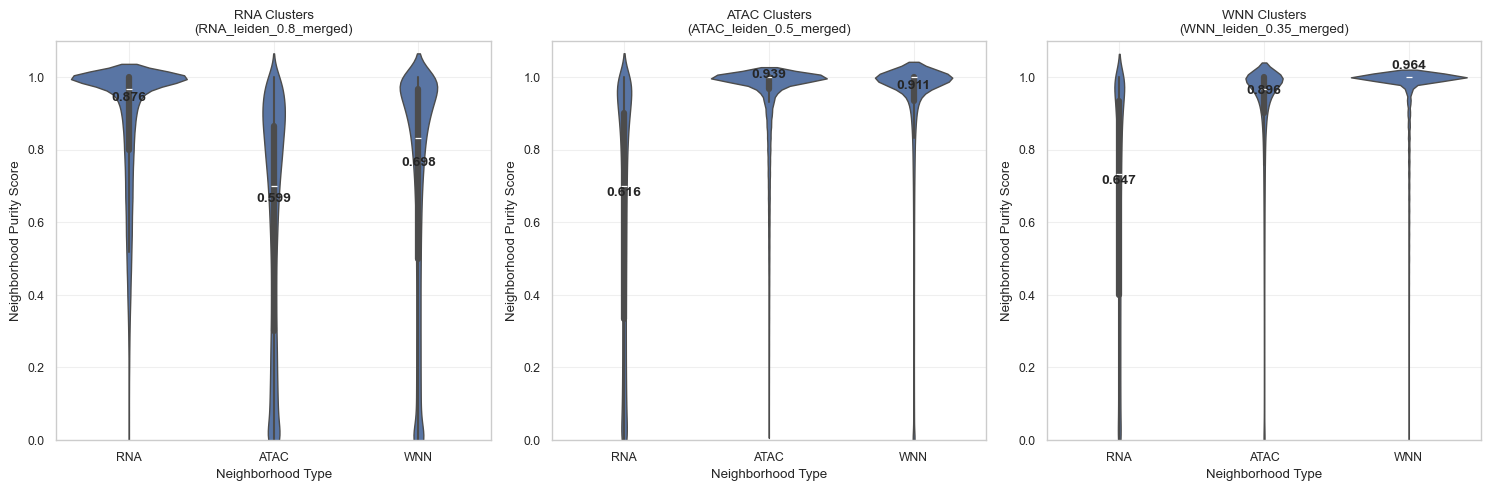

In [81]:
# Create visualization
fig = plot_comprehensive_neighborhood_purity(all_purity_results, adata, plot_type="violin")
plt.savefig(figpath + "neighborhood_purity_violin_all.pdf")
plt.show()


### Cross-modality comparison (ARI and NMI)

In [33]:
print("=" * 60)
print("2. CROSS-MODALITY VALIDATION")
print("=" * 60)

# Perform bidirectional cross-modality validation using existing cluster labels
validation_df = compute_bidirectional_cross_modality_validation(
    adata=adata,
    cluster_keys=cluster_keys
)

print(f"\n📊 Cross-Modality Validation Results:")
print(validation_df[['Reference_Modality', 'Target_Modality', 'ARI', 'NMI']].round(3))


2. CROSS-MODALITY VALIDATION

=== Using RNA as reference modality ===
Using reference clusters from RNA: RNA_leiden_0.8_merged
Found 23 unique clusters
Testing preservation in ATAC modality using ATAC_leiden_0.5_merged
Found 26 unique clusters in ATAC
  ARI: 0.330, NMI: 0.509
Testing preservation in WNN modality using WNN_leiden_0.35_merged
Found 27 unique clusters in WNN
  ARI: 0.330, NMI: 0.538

=== Using ATAC as reference modality ===
Using reference clusters from ATAC: ATAC_leiden_0.5_merged
Found 26 unique clusters
Testing preservation in RNA modality using RNA_leiden_0.8_merged
Found 23 unique clusters in RNA
  ARI: 0.330, NMI: 0.509
Testing preservation in WNN modality using WNN_leiden_0.35_merged
Found 27 unique clusters in WNN
  ARI: 0.622, NMI: 0.777

=== Using WNN as reference modality ===
Using reference clusters from WNN: WNN_leiden_0.35_merged
Found 27 unique clusters
Testing preservation in RNA modality using RNA_leiden_0.8_merged
Found 23 unique clusters in RNA
  ARI: 0

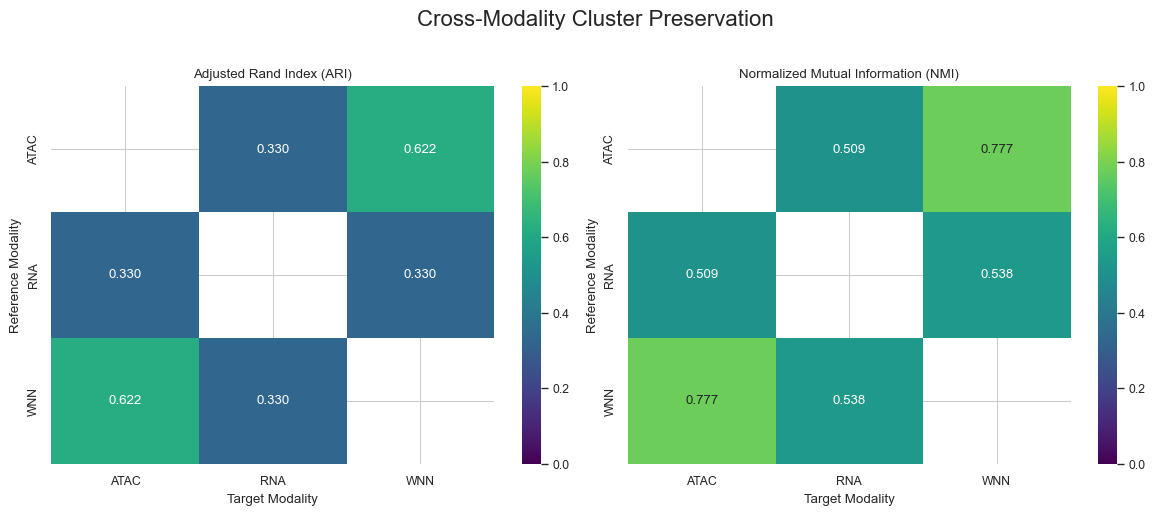


📈 Cross-Modality Summary:
  Metric   Mean    Std
0    ARI  0.427  0.151
1    NMI  0.608  0.131


In [36]:
# Create cross-modality validation plots
fig_cross = plot_cross_modality_validation(
    validation_df,
    figsize=(12, 5) 
)

plt.suptitle('Cross-Modality Cluster Preservation', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(figpath + "ARI_NMI_leiden_clusters.pdf")
plt.show()

# Summarize cross-modality results
summary_cross = summarize_cross_modality_validation(validation_df)
print(f"\n📈 Cross-Modality Summary:")
print(summary_cross[summary_cross['Category'] == 'Overall'][['Metric', 'Mean', 'Std']].round(3))


In [37]:
adata.obs["rna_weights"] = rna_weights["x"].values

In [38]:
# save the adata
adata.write_h5ad("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data/01_Signac_processed/integrated_RNA_ATAC_counts_master_nn_computed.h5ad")

RNA Weight Summary by Cell Type:
                              mean  median    std
Cell_type                                        
neural_telencephalon         0.270   0.268  0.203
primordial_germ_cells        0.288   0.289  0.180
neural_floor_plate           0.402   0.410  0.148
hindbrain                    0.412   0.435  0.150
neural_posterior             0.420   0.429  0.153
floor_plate                  0.421   0.438  0.150
neurons                      0.433   0.447  0.141
tail_bud                     0.435   0.441  0.137
midbrain_hindbrain_boundary  0.438   0.445  0.137
neural_optic                 0.440   0.455  0.142
NMPs                         0.443   0.450  0.122
PSM                          0.444   0.450  0.140
spinal_cord                  0.445   0.459  0.136
pronephros                   0.445   0.468  0.132
optic_cup                    0.448   0.463  0.180
neural                       0.448   0.455  0.130
endoderm                     0.453   0.478  0.127
epidermis        

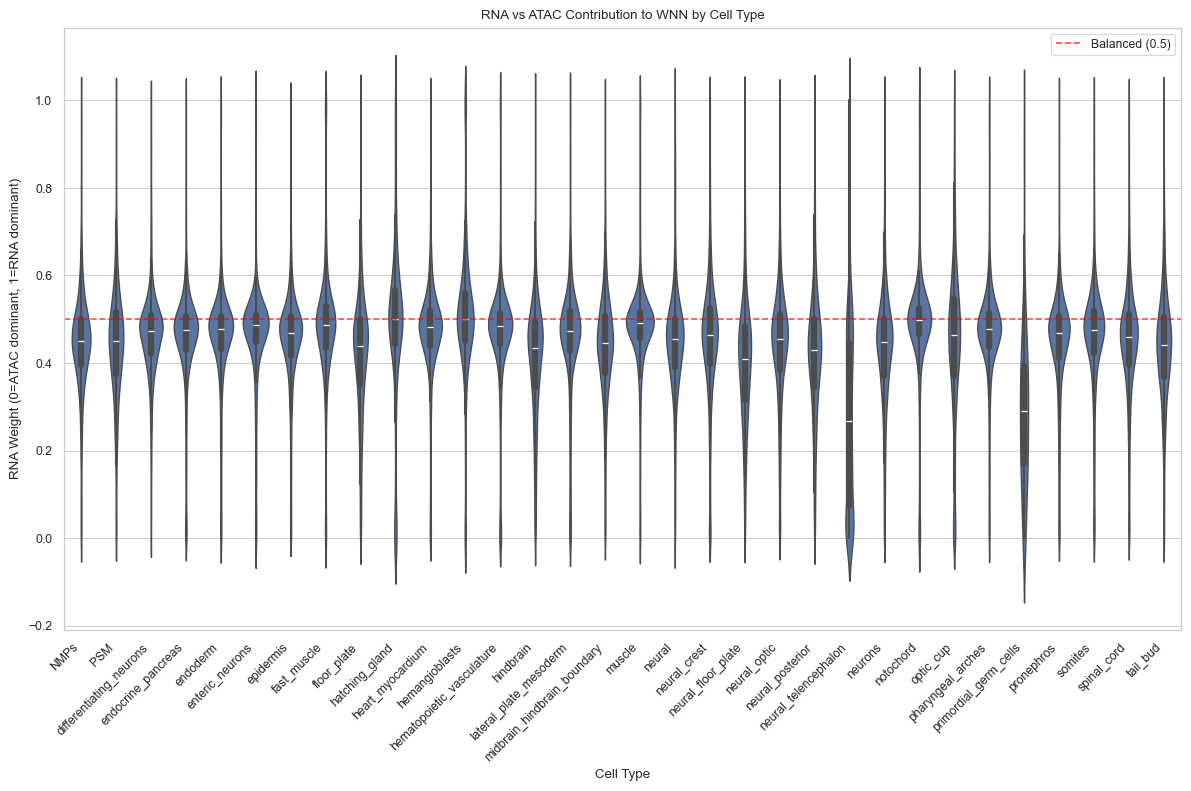

In [39]:
# Create violin plot of RNA weights by cell type
def plot_rna_weights_by_celltype(adata, groupby='annotation_ML_coarse', figsize=(12, 8)):
    """
    Plot violin plot of RNA weights by cell type annotation
    """
    # Extract data for plotting
    plot_data = pd.DataFrame({
        'RNA_weight': adata.obs['rna_weights'].values,
        'Cell_type': adata.obs[groupby].values
    })
    
    # Create the plot
    plt.figure(figsize=figsize)
    
    # Violin plot
    ax = sns.violinplot(data=plot_data, x='Cell_type', y='RNA_weight', 
                       inner='box', linewidth=1)
    
    # Add horizontal line at 0.5 (balanced weighting)
    plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.7, 
                label='Balanced (0.5)')
    
    # Formatting
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('RNA Weight (0=ATAC dominant, 1=RNA dominant)')
    plt.xlabel('Cell Type')
    plt.title('RNA vs ATAC Contribution to WNN by Cell Type')
    plt.legend()
    plt.tight_layout()
    
    # Print summary statistics
    print("RNA Weight Summary by Cell Type:")
    summary = plot_data.groupby('Cell_type')['RNA_weight'].agg(['mean', 'median', 'std']).round(3)
    print(summary.sort_values('mean'))
    
    # Overall statistics
    overall_mean = plot_data['RNA_weight'].mean()
    atac_dominant = (plot_data['RNA_weight'] < 0.5).sum() / len(plot_data) * 100
    
    print(f"\nOverall RNA weight mean: {overall_mean:.3f}")
    print(f"Cells with ATAC-dominant weighting (<0.5): {atac_dominant:.1f}%")
    
    return plot_data

# Create the plot
plot_data = plot_rna_weights_by_celltype(adata)
plt.show()

/tmp/ipykernel_1292552/2871772393.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=plot_data, x='Cell_type', y='RNA_weight',


RNA Weight Summary by Cell Type:
                              mean  median    std
Cell_type                                        
neural_telencephalon         0.270   0.268  0.203
primordial_germ_cells        0.288   0.289  0.180
neural_floor_plate           0.402   0.410  0.148
hindbrain                    0.412   0.435  0.150
neural_posterior             0.420   0.429  0.153
floor_plate                  0.421   0.438  0.150
neurons                      0.433   0.447  0.141
tail_bud                     0.435   0.441  0.137
midbrain_hindbrain_boundary  0.438   0.445  0.137
neural_optic                 0.440   0.455  0.142
NMPs                         0.443   0.450  0.122
PSM                          0.444   0.450  0.140
spinal_cord                  0.445   0.459  0.136
pronephros                   0.445   0.468  0.132
optic_cup                    0.448   0.463  0.180
neural                       0.448   0.455  0.130
endoderm                     0.453   0.478  0.127
epidermis        

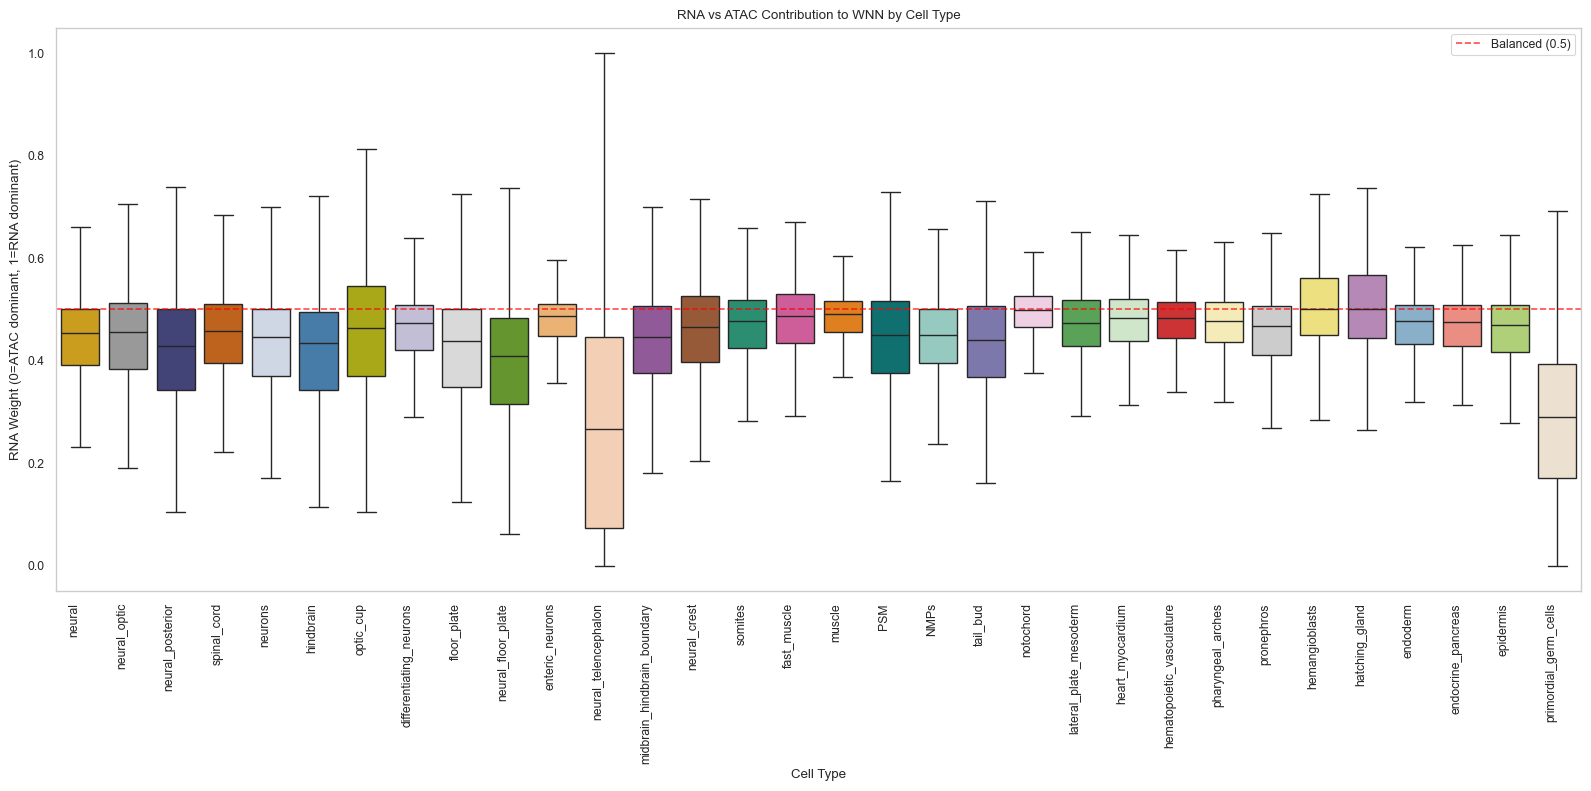

In [86]:
# Create boxplot of RNA weights by cell type with custom ordering and colors
def plot_rna_weights_by_celltype(adata, groupby='annotation_ML_coarse', figsize=(16, 8)):
    """
    Plot boxplot of RNA weights by cell type annotation with custom ordering and colors
    """
    # Define cell type color palette
    cell_type_color_dict = {
        'NMPs': '#8dd3c7',
        'PSM': '#008080',
        'differentiating_neurons': '#bebada',
        'endocrine_pancreas': '#fb8072',
        'endoderm': '#80b1d3',
        'enteric_neurons': '#fdb462',
        'epidermis': '#b3de69',
        'fast_muscle': '#df4b9b',
        'floor_plate': '#d9d9d9',
        'hatching_gland': '#bc80bd',
        'heart_myocardium': '#ccebc5',
        'hemangioblasts': '#ffed6f',
        'hematopoietic_vasculature': '#e41a1c',
        'hindbrain': '#377eb8',
        'lateral_plate_mesoderm': '#4daf4a',
        'midbrain_hindbrain_boundary': '#984ea3',
        'muscle': '#ff7f00',
        'neural': '#e6ab02',
        'neural_crest': '#a65628',
        'neural_floor_plate': '#66a61e',
        'neural_optic': '#999999',
        'neural_posterior': '#393b7f',
        'neural_telencephalon': '#fdcdac',
        'neurons': '#cbd5e8',
        'notochord': '#f4cae4',
        'optic_cup': '#c0c000',
        'pharyngeal_arches': '#fff2ae',
        'primordial_germ_cells': '#f1e2cc',
        'pronephros': '#cccccc',
        'somites': '#1b9e77',
        'spinal_cord': '#d95f02',
        'tail_bud': '#7570b3'
    }
    
    # Define cell type order by lineage
    celltype_order = [
        # CNS
        "neural", "neural_optic", "neural_posterior", "spinal_cord", "neurons", 
        "hindbrain", "optic_cup", "differentiating_neurons", "floor_plate", 
        "neural_floor_plate", "enteric_neurons", "neural_telencephalon", 
        "midbrain_hindbrain_boundary",
        # Neural Crest  
        "neural_crest",
        # Paraxial Mesoderm
        "somites", "fast_muscle", "muscle", "PSM", "NMPs", "tail_bud", "notochord",
        # Lateral Mesoderm
        "lateral_plate_mesoderm", "heart_myocardium", "hematopoietic_vasculature", 
        "pharyngeal_arches", "pronephros", "hemangioblasts", "hatching_gland",
        # Endoderm
        "endoderm", "endocrine_pancreas",
        # Epiderm
        "epidermis",
        # Germline
        "primordial_germ_cells"
    ]
    
    # Extract data for plotting
    plot_data = pd.DataFrame({
        'RNA_weight': adata.obs['rna_weights'].values,
        'Cell_type': adata.obs[groupby].values
    })
    
    # Filter to only include cell types that exist in data and are in our order list
    existing_celltypes = plot_data['Cell_type'].unique()
    ordered_existing = [ct for ct in celltype_order if ct in existing_celltypes]
    
    # Filter plot_data to only include ordered cell types
    plot_data = plot_data[plot_data['Cell_type'].isin(ordered_existing)]
    
    # Create colors list in the same order
    colors = [cell_type_color_dict[ct] for ct in ordered_existing]
    
    # Create the plot
    plt.figure(figsize=figsize)
    
    # Boxplot with custom colors
    ax = sns.boxplot(data=plot_data, x='Cell_type', y='RNA_weight', 
                     order=ordered_existing, palette=colors,
                     linewidth=1, showfliers=False)
    
    # Add horizontal line at 0.5 (balanced weighting)
    plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.7, 
                label='Balanced (0.5)')
    
    # Formatting
    plt.xticks(rotation=90, ha='right')
    plt.ylabel('RNA Weight (0=ATAC dominant, 1=RNA dominant)')
    plt.xlabel('Cell Type')
    plt.title('RNA vs ATAC Contribution to WNN by Cell Type')
    plt.grid(False)
    plt.legend()
    plt.tight_layout()
    
    # Print summary statistics
    print("RNA Weight Summary by Cell Type:")
    summary = plot_data.groupby('Cell_type')['RNA_weight'].agg(['mean', 'median', 'std']).round(3)
    print(summary.sort_values('mean'))
    
    # Overall statistics
    overall_mean = plot_data['RNA_weight'].mean()
    atac_dominant = (plot_data['RNA_weight'] < 0.5).sum() / len(plot_data) * 100
    
    print(f"\nOverall RNA weight mean: {overall_mean:.3f}")
    print(f"Cells with ATAC-dominant weighting (<0.5): {atac_dominant:.1f}%")
    
    return plot_data

# Create the plot
plot_data = plot_rna_weights_by_celltype(adata)
plt.savefig(figpath+"rna_weights_by_celltypes.pdf")
plt.show()

### Optional: Trajectory conservation

In [51]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from typing import Dict, List, Tuple
from scipy import sparse
from sklearn.metrics import silhouette_score

def compute_trajectory_ordering_score(pseudotime, cell_types, expected_order):
    """
    Compute how well pseudotime preserves the expected developmental ordering
    """
    
    # For each cell type, compute median pseudotime
    type_medians = {}
    for cell_type in expected_order:
        type_mask = cell_types == cell_type
        if type_mask.sum() > 0:
            type_medians[cell_type] = np.median(pseudotime[type_mask])
    
    if len(type_medians) < 2:
        return 0.0
    
    # Check if median pseudotimes follow expected order
    median_values = [type_medians.get(ct, np.inf) for ct in expected_order if ct in type_medians]
    
    if len(median_values) < 2:
        return 0.0
    
    # Compute Pearson correlation with expected ordering
    expected_ranks = list(range(len(median_values)))
    
    # Sort median values and get their ranks
    sorted_indices = np.argsort(median_values)
    rank_correlation = np.corrcoef(expected_ranks, sorted_indices)[0, 1]
    
    # Convert to 0-1 scale
    ordering_score = (rank_correlation + 1) / 2 if not np.isnan(rank_correlation) else 0.0
    
    return ordering_score

def robust_diffmap_and_dpt(adata_mod, n_dcs=10, max_cells=15000):
    """
    Robust diffusion map and DPT computation with error handling
    """
    
    # If too many cells, subsample for stability
    if adata_mod.n_obs > max_cells:
        print(f"Subsampling from {adata_mod.n_obs} to {max_cells} cells for stability")
        sc.pp.subsample(adata_mod, n_obs=max_cells)
    
    # Clean up connectivity matrix
    connectivities = adata_mod.obsp['connectivities'].copy()
    
    # Remove cells with no connections (isolated nodes)
    node_degrees = np.array(connectivities.sum(axis=1)).flatten()
    connected_mask = node_degrees > 0
    
    if connected_mask.sum() < adata_mod.n_obs * 0.8:
        print(f"Warning: {(~connected_mask).sum()} cells have no connections, removing them")
        adata_mod = adata_mod[connected_mask].copy()
        
        # Update connectivity matrix
        connectivities = adata_mod.obsp['connectivities']
    
    # Ensure matrix is symmetric and normalized
    connectivities = (connectivities + connectivities.T) / 2
    
    # Add small diagonal regularization to avoid numerical issues
    connectivities.setdiag(1e-6)
    
    # Normalize rows to sum to 1
    row_sums = np.array(connectivities.sum(axis=1)).flatten()
    row_sums[row_sums == 0] = 1  # Avoid division by zero
    normalizer = sparse.diags(1.0 / row_sums)
    connectivities = normalizer @ connectivities
    
    adata_mod.obsp['connectivities'] = connectivities
    adata_mod.obsp['distances'] = connectivities.copy()  # Use same for distances
    
    try:
        # Try with fewer components first
        reduced_comps = min(n_dcs, 10)
        sc.tl.diffmap(adata_mod, n_comps=reduced_comps)
        
        # Set root and compute DPT
        root_mask = adata_mod.obs['annotation_ML_coarse'] == 'NMPs'
        if root_mask.sum() > 0:
            root_indices = np.where(root_mask)[0]
            if len(root_indices) > 0:
                # Use first NMP cell as root for simplicity
                adata_mod.uns['iroot'] = root_indices[0]
                sc.tl.dpt(adata_mod, n_dcs=reduced_comps)
                return True
        
        return False
        
    except Exception as e:
        print(f"Diffusion map failed even with regularization: {str(e)}")
        return False

def compute_bifurcated_trajectory_conservation_robust(
    adata: sc.AnnData,
    neighbors_keys: Dict[str, str],
    root_cluster: str = 'NMPs',
    mesodermal_trajectory: List[str] = ['NMPs', 'tail_bud', 'PSM', 'somites', 'fast_muscle'],
    neural_trajectory: List[str] = ['NMPs', 'spinal_cord', 'neural_posterior'],
    n_dcs: int = 10,
    max_cells: int = 15000
) -> Dict[str, Dict[str, float]]:
    """
    Robust trajectory conservation computation with error handling
    """
    
    # Combine all trajectory cell types
    all_trajectory_types = list(set(mesodermal_trajectory + neural_trajectory))
    trajectory_mask = adata.obs['annotation_ML_coarse'].isin(all_trajectory_types)
    adata_traj = adata[trajectory_mask].copy()
    
    print(f"Analyzing bifurcated trajectories with {adata_traj.n_obs} cells across {len(all_trajectory_types)} cell types")
    print(f"Mesodermal branch: {' -> '.join(mesodermal_trajectory)}")
    print(f"Neural branch: {' -> '.join(neural_trajectory)}")
    
    trajectory_results = {}
    
    for modality_name, neighbors_key in neighbors_keys.items():
        print(f"\n=== Analyzing {modality_name} modality using {neighbors_key} ===")
        
        try:
            # Check if the connectivity matrix exists
            if neighbors_key not in adata_traj.obsp.keys():
                print(f"Warning: {neighbors_key} not found in adata.obsp")
                continue
            
            # Prepare data for this modality
            adata_mod = adata_traj.copy()
            
            # Set up connectivity matrix
            adata_mod.obsp['connectivities'] = adata_traj.obsp[neighbors_key].copy()
            
            # Set up neighbors metadata (required by scanpy)
            n_neighbors = min(30, int(adata_mod.obsp['connectivities'].getnnz() / adata_mod.n_obs))
            
            adata_mod.uns['neighbors'] = {
                'connectivities_key': 'connectivities',
                'distances_key': 'connectivities',  # Use same matrix
                'params': {
                    'n_neighbors': n_neighbors,
                    'method': 'precomputed',
                    'metric': 'precomputed'
                }
            }
            
            # Robust diffusion map computation
            diffmap_success = robust_diffmap_and_dpt(adata_mod, n_dcs, max_cells)
            
            if not diffmap_success:
                print(f"Failed to compute diffusion map for {modality_name}")
                trajectory_results[modality_name] = {
                    'mesodermal_conservation': 0.0,
                    'neural_conservation': 0.0,
                    'bifurcation_quality': 0.0,
                    'overall_trajectory_score': 0.0
                }
                continue
            
            # Get pseudotime values
            if 'dpt_pseudotime' not in adata_mod.obs.columns:
                print(f"No pseudotime computed for {modality_name}")
                continue
                
            pseudotime = adata_mod.obs['dpt_pseudotime'].values
            cell_types = adata_mod.obs['annotation_ML_coarse'].values
            
            # Check for valid pseudotime
            if np.isnan(pseudotime).all():
                print(f"All pseudotime values are NaN for {modality_name}")
                continue
            
            # Analyze each trajectory branch
            branch_results = {}
            
            # 1. Mesodermal trajectory analysis
            meso_cells = np.isin(cell_types, mesodermal_trajectory)
            if meso_cells.sum() > 5:  # Reduced threshold
                meso_pseudotime = pseudotime[meso_cells]
                meso_celltypes = cell_types[meso_cells]
                
                # Filter out NaN values
                valid_mask = ~np.isnan(meso_pseudotime)
                if valid_mask.sum() > 2:
                    meso_score = compute_trajectory_ordering_score(
                        meso_pseudotime[valid_mask], meso_celltypes[valid_mask], mesodermal_trajectory
                    )
                    branch_results['mesodermal_conservation'] = meso_score
                else:
                    branch_results['mesodermal_conservation'] = 0.0
            else:
                branch_results['mesodermal_conservation'] = 0.0
            
            # 2. Neural trajectory analysis  
            neural_cells = np.isin(cell_types, neural_trajectory)
            if neural_cells.sum() > 5:
                neural_pseudotime = pseudotime[neural_cells]
                neural_celltypes = cell_types[neural_cells]
                
                # Filter out NaN values
                valid_mask = ~np.isnan(neural_pseudotime)
                if valid_mask.sum() > 2:
                    neural_score = compute_trajectory_ordering_score(
                        neural_pseudotime[valid_mask], neural_celltypes[valid_mask], neural_trajectory
                    )
                    branch_results['neural_conservation'] = neural_score
                else:
                    branch_results['neural_conservation'] = 0.0
            else:
                branch_results['neural_conservation'] = 0.0
            
            # 3. Bifurcation quality - simplified version
            bifurcation_score = compute_simple_bifurcation_score(
                adata_mod, mesodermal_trajectory, neural_trajectory, root_cluster
            )
            branch_results['bifurcation_quality'] = bifurcation_score
            
            # 4. Overall trajectory score
            branch_results['overall_trajectory_score'] = np.mean([
                branch_results['mesodermal_conservation'],
                branch_results['neural_conservation'], 
                branch_results['bifurcation_quality']
            ])
            
            trajectory_results[modality_name] = branch_results
            
            print(f"{modality_name} results:")
            print(f"  Mesodermal conservation: {branch_results['mesodermal_conservation']:.3f}")
            print(f"  Neural conservation: {branch_results['neural_conservation']:.3f}")
            print(f"  Bifurcation quality: {branch_results['bifurcation_quality']:.3f}")
            print(f"  Overall score: {branch_results['overall_trajectory_score']:.3f}")
            
        except Exception as e:
            print(f"Error analyzing {modality_name}: {str(e)}")
            trajectory_results[modality_name] = {
                'mesodermal_conservation': 0.0,
                'neural_conservation': 0.0,
                'bifurcation_quality': 0.0,
                'overall_trajectory_score': 0.0
            }
    
    return trajectory_results

def compute_simple_bifurcation_score(adata_mod, mesodermal_trajectory, neural_trajectory, root_cluster):
    """
    Simplified bifurcation score using pseudotime differences
    """
    
    try:
        pseudotime = adata_mod.obs['dpt_pseudotime'].values
        cell_types = adata_mod.obs['annotation_ML_coarse'].values
        
        # Get terminal cell types from each branch
        meso_terminals = ['fast_muscle', 'somites']
        neural_terminals = ['neural_posterior', 'spinal_cord']
        
        meso_pseudotimes = []
        for ct in meso_terminals:
            mask = cell_types == ct
            if mask.sum() > 0:
                pt_values = pseudotime[mask]
                valid_pt = pt_values[~np.isnan(pt_values)]
                if len(valid_pt) > 0:
                    meso_pseudotimes.extend(valid_pt)
        
        neural_pseudotimes = []
        for ct in neural_terminals:
            mask = cell_types == ct
            if mask.sum() > 0:
                pt_values = pseudotime[mask]
                valid_pt = pt_values[~np.isnan(pt_values)]
                if len(valid_pt) > 0:
                    neural_pseudotimes.extend(valid_pt)
        
        if len(meso_pseudotimes) > 0 and len(neural_pseudotimes) > 0:
            meso_mean = np.mean(meso_pseudotimes)
            neural_mean = np.mean(neural_pseudotimes)
            
            # Simple separation score based on pseudotime difference
            separation = abs(meso_mean - neural_mean)
            # Normalize to 0-1 using sigmoid
            bifurcation_score = 1 / (1 + np.exp(-separation * 2))
            return bifurcation_score
        
        return 0.0
        
    except Exception:
        return 0.0

# Main function with robust error handling
def run_robust_bifurcated_trajectory_analysis(
    adata: sc.AnnData,
    neighbors_keys: Dict[str, str] = None,
    max_cells: int = 15000
) -> Dict[str, Dict[str, float]]:
    """
    Robust bifurcated trajectory analysis with comprehensive error handling
    """
    
    if neighbors_keys is None:
        neighbors_keys = {
            'RNA': 'RNA_connectivities',
            'ATAC': 'ATAC_connectivities',
            'WNN': 'connectivities_wnn'
        }
    
    print("=== Robust Bifurcated NMP Trajectory Analysis ===")
    print(f"Using max {max_cells} cells per analysis for numerical stability")
    
    # Define trajectories
    mesodermal_trajectory = ['NMPs', 'tail_bud', 'PSM', 'somites', 'fast_muscle']
    neural_trajectory = ['NMPs', 'spinal_cord', 'neural_posterior']
    
    # Compute trajectory conservation scores
    trajectory_results = compute_bifurcated_trajectory_conservation_robust(
        adata=adata,
        neighbors_keys=neighbors_keys,
        mesodermal_trajectory=mesodermal_trajectory,
        neural_trajectory=neural_trajectory,
        max_cells=max_cells
    )
    
    # Print summary
    print(f"\n=== Final Results Summary ===")
    print(f"{'Modality':<8} {'Mesodermal':<12} {'Neural':<10} {'Bifurcation':<12} {'Overall':<8}")
    print("-" * 60)
    
    for modality, results in trajectory_results.items():
        print(f"{modality:<8} {results['mesodermal_conservation']:<12.3f} {results['neural_conservation']:<10.3f} "
              f"{results['bifurcation_quality']:<12.3f} {results['overall_trajectory_score']:<8.3f}")
    
    return trajectory_results

# Usage
neighbors_keys = {
    'RNA': 'RNA_connectivities',
    'ATAC': 'ATAC_connectivities', 
    'WNN': 'connectivities_wnn'
}

trajectory_results = run_robust_bifurcated_trajectory_analysis(
    adata, neighbors_keys, max_cells=10000  # Reduce if still having issues
)

=== Robust Bifurcated NMP Trajectory Analysis ===
Using max 10000 cells per analysis for numerical stability
Analyzing bifurcated trajectories with 24254 cells across 7 cell types
Mesodermal branch: NMPs -> tail_bud -> PSM -> somites -> fast_muscle
Neural branch: NMPs -> spinal_cord -> neural_posterior

=== Analyzing RNA modality using RNA_connectivities ===
Subsampling from 24254 to 10000 cells for stability


/hpc/user_apps/data.science/conda_envs/sc_rapids/lib/python3.10/site-packages/scipy/sparse/_index.py:145: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)


RNA results:
  Mesodermal conservation: 0.700
  Neural conservation: 1.000
  Bifurcation quality: nan
  Overall score: nan

=== Analyzing ATAC modality using ATAC_connectivities ===
Subsampling from 24254 to 10000 cells for stability


/tmp/ipykernel_1292552/700544413.py:287: RuntimeWarning: invalid value encountered in scalar subtract
  separation = abs(meso_mean - neural_mean)
/hpc/user_apps/data.science/conda_envs/sc_rapids/lib/python3.10/site-packages/scipy/sparse/_index.py:145: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)


ATAC results:
  Mesodermal conservation: 0.700
  Neural conservation: 0.250
  Bifurcation quality: nan
  Overall score: nan

=== Analyzing WNN modality using connectivities_wnn ===
Subsampling from 24254 to 10000 cells for stability


/tmp/ipykernel_1292552/700544413.py:287: RuntimeWarning: invalid value encountered in scalar subtract
  separation = abs(meso_mean - neural_mean)


WNN results:
  Mesodermal conservation: 0.800
  Neural conservation: 1.000
  Bifurcation quality: nan
  Overall score: nan

=== Final Results Summary ===
Modality Mesodermal   Neural     Bifurcation  Overall 
------------------------------------------------------------
RNA      0.700        1.000      nan          nan     
ATAC     0.700        0.250      nan          nan     
WNN      0.800        1.000      nan          nan     


/tmp/ipykernel_1292552/700544413.py:287: RuntimeWarning: invalid value encountered in scalar subtract
  separation = abs(meso_mean - neural_mean)


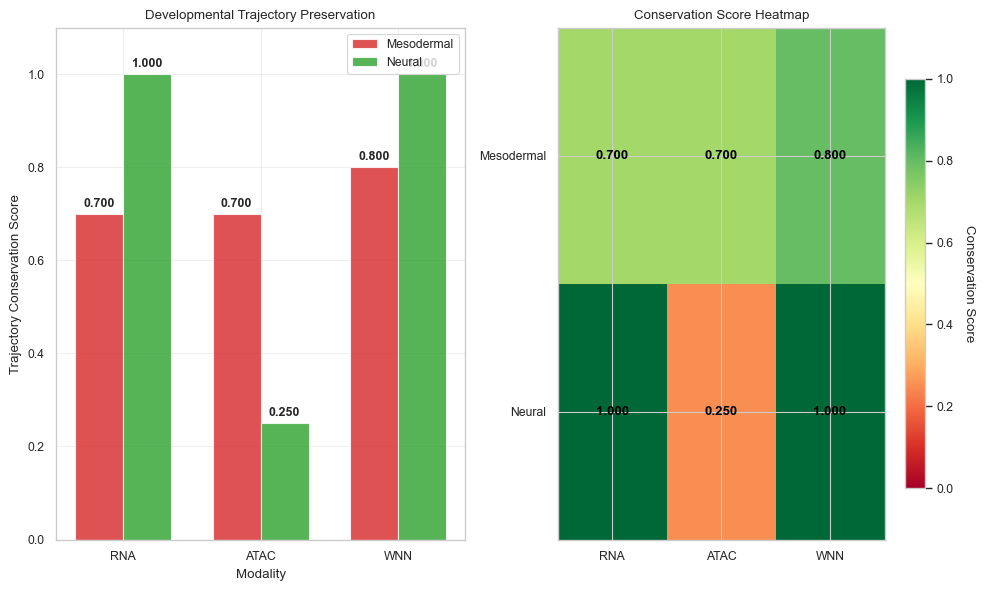


=== Summary for Manuscript ===
Trajectory Conservation Scores (0-1, higher = better):
Modality Mesodermal   Neural    
--------------------------------
RNA      0.700        1.000     
ATAC     0.700        0.250     
WNN      0.800        1.000     


In [85]:
def plot_trajectory_conservation_results(trajectory_results, figsize=(10, 6)):
    """
    Visualize trajectory conservation results
    """
    
    # Extract data, filtering out NaN bifurcation scores
    modalities = list(trajectory_results.keys())
    meso_scores = [trajectory_results[mod]['mesodermal_conservation'] for mod in modalities]
    neural_scores = [trajectory_results[mod]['neural_conservation'] for mod in modalities]
    
    # Create subplot layout
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    
    # Bar plot comparison
    x = np.arange(len(modalities))
    width = 0.35
    
    bars1 = ax1.bar(x - width/2, meso_scores, width, label='Mesodermal', alpha=0.8, color='#d62728')
    bars2 = ax1.bar(x + width/2, neural_scores, width, label='Neural', alpha=0.8, color='#2ca02c')
    
    ax1.set_xlabel('Modality')
    ax1.set_ylabel('Trajectory Conservation Score')
    ax1.set_title('Developmental Trajectory Preservation')
    ax1.set_xticks(x)
    ax1.set_xticklabels(modalities)
    ax1.legend()
    ax1.set_ylim(0, 1.1)
    ax1.grid(True, alpha=0.3)
    
    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax1.annotate(f'{height:.3f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # Heatmap representation
    data_matrix = np.array([meso_scores, neural_scores])
    im = ax2.imshow(data_matrix, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
    
    ax2.set_xticks(range(len(modalities)))
    ax2.set_xticklabels(modalities)
    ax2.set_yticks([0, 1])
    ax2.set_yticklabels(['Mesodermal', 'Neural'])
    ax2.set_title('Conservation Score Heatmap')
    
    # Add text annotations to heatmap
    for i in range(2):
        for j in range(len(modalities)):
            text = ax2.text(j, i, f'{data_matrix[i, j]:.3f}',
                           ha="center", va="center", color="black", fontweight='bold')
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax2, shrink=0.8)
    cbar.set_label('Conservation Score', rotation=270, labelpad=15)
    
    plt.tight_layout()
    return fig

# Create the visualization
fig = plot_trajectory_conservation_results(trajectory_results)
plt.savefig(figpath + "trajectory_conservation_scores_meso_neuro.pdf")
plt.show()

# Summary table for manuscript
print("\n=== Summary for Manuscript ===")
print("Trajectory Conservation Scores (0-1, higher = better):")
print(f"{'Modality':<8} {'Mesodermal':<12} {'Neural':<10}")
print("-" * 32)
for modality, results in trajectory_results.items():
    print(f"{modality:<8} {results['mesodermal_conservation']:<12.3f} {results['neural_conservation']:<10.3f}")